## Part 1 - Warm-up: one-variable example with $x^2$

Before the 2-variable example, here is a tiny warm-up:

$$
f(x)=x^2
$$

Manual derivative:

$$
\frac{df}{dx}=2x
$$

At $x=3$, the gradient should be $6$.

In [8]:
def f(x):
    return x**2


def grad_f(x):
    return 2.0 * x


x = 3.0
print('f(3) =', f(x))
print('manual df/dx at x=3 =', grad_f(x))

f(3) = 9.0
manual df/dx at x=3 = 6.0


In [9]:
import torch

x_t = torch.tensor(3.0, requires_grad=True)
g = x_t**2
g.backward()

print('autograd df/dx at x=3 =', x_t.grad.item())
assert abs(x_t.grad.item() - grad_f(3.0)) < 1e-9
print('Passed: manual and autograd match for x^2.')

autograd df/dx at x=3 = 6.0
Passed: manual and autograd match for x^2.


# Part 2 - Manual Gradients & Autograd

1. Computing gradients manually (no autograd)
2. Verifying them with PyTorch autograd

$$
f(x,y)=4xy + 3(x+2y)
$$

at the test point $(x,y)=(2,3).$

## Step 1: Build the computational graph with intermediate variables

For this example, define:

$$
\begin{aligned}
q_1 &= xy \\
q_2 &= x+2y \\
f &= 4q_1 + 3q_2
\end{aligned}
$$

This still demonstrates gradient accumulation, and local derivatives are not all equal to 1.

In [4]:
def f_value(x, y):
    q1 = x * y
    q2 = x + 2.0 * y
    f = 4.0 * q1 + 3.0 * q2
    return f

print('f(2,3) =', f_value(2.0, 3.0))

f(2,3) = 48.0


## Step 2: Manual gradient functions (chain rule)
![Expression graph](expression.png)
### Backpropagation Explained: From `f` to `x` and `y`

This process breaks down how a change in inputs `x` and `y` affects the final output `f` by propagating gradients backward through the computation graph.

---

### 1. The Forward Pass
First, we compute the output `f` for a given set of inputs, for example, `x=2` and `y=3`.

| Variable | Equation | Calculation | Result |
| :--- | :--- | :--- | :--- |
| `q₁` | `x * y` | `2 * 3` | `6` |
| `q₂` | `x + 2y` | `2 + 2 * 3` | `8` |
| `f` | `4q₁ + 3q₂` | `4 * 6 + 3 * 8` | `48` |

---

### 2. The Backward Pass (Backpropagation)
The goal is to calculate the gradients `∂f/∂x` and `∂f/∂y` by applying the chain rule. We start from the output `f` and move backward.

#### **Step 1: Compute Local Derivatives**
At each node in the graph, we find the local derivative of that node's output with respect to its immediate inputs.

| Node Operation | Local Derivative |
| :--- | :--- |
| `f = 4q₁ + 3q₂` | `∂f/∂q₁ = 4` <br> `∂f/∂q₂ = 3` |
| `q₁ = x * y` | `∂q₁/∂x = y` <br> `∂q₁/∂y = x` |
| `q₂ = x + 2y` | `∂q₂/∂x = 1` <br> `∂q₂/∂y = 2` |

#### **Step 2: Propagate Gradients Backward**
We use the chain rule to multiply the local derivatives along each path from the output `f` back to the inputs `x` and `y`.

**Gradient with respect to `x` (`∂f/∂x`)**
The input `x` affects `f` through two paths. We calculate the gradient for each path and sum them up.

| Path | Chain Rule Application | Result |
| :--- | :--- | :--- |
| `x → q₁ → f` | `(∂f/∂q₁) * (∂q₁/∂x)` | `4 * y` |
| `x → q₂ → f` | `(∂f/∂q₂) * (∂q₂/∂x)` | `3 * 1` |
| **Total `∂f/∂x`** | | **`4y + 3`** |

**Gradient with respect to `y` (`∂f/∂y`)**
Similarly, the input `y` affects `f` through two paths.

| Path | Chain Rule Application | Result |
| :--- | :--- | :--- |
| `y → q₁ → f` | `(∂f/∂q₁) * (∂q₁/∂y)` | `4 * x` |
| `y → q₂ → f` | `(∂f/∂q₂) * (∂q₂/∂y)` | `3 * 2` |
| **Total `∂f/∂y`** | | **`4x + 6`** |

---

### 3. Final Calculation at (x=2, y=3)
Using the final gradient expressions, we can compute the numerical gradients at our specific input values.

*   **`∂f/∂x`** = 4y + 3 = 4(3) + 3 = **15**
*   **`∂f/∂y`** = 4x + 6 = 4(2) + 6 = **14**

### ✨ Key Insight of Backpropagation

The efficiency of backpropagation comes from its **"compute once, reuse often"** strategy. 
* Each local derivative (like `∂f/∂q₁` or `∂q₁/∂x`) is calculated only a single time during the backward pass. 
* These values are then reused in the chain rule for all paths that pass through that node, which drastically reduces redundant computations. 
* This is the fundamental principle that allows modern deep learning frameworks to train complex models efficiently.

In [5]:
def grad_x_manual(x, y):
    # Forward values
    q1 = x * y
    q2 = x + 2.0 * y

    # Local derivatives
    df_dq1 = 4.0
    df_dq2 = 3.0
    dq1_dx = y
    dq2_dx = 1.0

    # x has two paths to f: x->q1->f and x->q2->f
    grad_x = df_dq1 * dq1_dx + df_dq2 * dq2_dx
    return grad_x


def grad_y_manual(x, y):
    # Forward values
    q1 = x * y
    q2 = x + 2.0 * y

    # Local derivatives
    df_dq1 = 4.0
    df_dq2 = 3.0
    dq1_dy = x
    dq2_dy = 2.0

    # y has two paths to f: y->q1->f and y->q2->f
    grad_y = df_dq1 * dq1_dy + df_dq2 * dq2_dy
    return grad_y


x0, y0 = 2.0, 3.0
gx_manual = grad_x_manual(x0, y0)
gy_manual = grad_y_manual(x0, y0)

print('Manual gradients at (2,3):')
print('df/dx =', gx_manual)
print('df/dy =', gy_manual)

Manual gradients at (2,3):
df/dx = 15.0
df/dy = 14.0


## Step 3: Autograd implementation for verification

In [6]:
import torch

def autograd_gradients(x, y):
    x_t = torch.tensor(float(x), requires_grad=True)
    y_t = torch.tensor(float(y), requires_grad=True)

    f = 4.0 * (x_t * y_t) + 3.0 * (x_t + 2.0 * y_t)
    f.backward()

    return x_t.grad.item(), y_t.grad.item()


gx_auto, gy_auto = autograd_gradients(2.0, 3.0)

print('Autograd gradients at (2,3):')
print('df/dx =', gx_auto)
print('df/dy =', gy_auto)

Autograd gradients at (2,3):
df/dx = 15.0
df/dy = 14.0


## Step 4: Compare manual vs autograd

In [7]:
tol = 1e-9

print('Comparison at (2,3):')
print(f'df/dx manual = {gx_manual:.10f}, autograd = {gx_auto:.10f}')
print(f'df/dy manual = {gy_manual:.10f}, autograd = {gy_auto:.10f}')

assert abs(gx_manual - gx_auto) < tol, 'df/dx mismatch!'
assert abs(gy_manual - gy_auto) < tol, 'df/dy mismatch!'
print('\nPassed: manual gradients match autograd.')

Comparison at (2,3):
df/dx manual = 15.0000000000, autograd = 15.0000000000
df/dy manual = 14.0000000000, autograd = 14.0000000000

Passed: manual gradients match autograd.


# Part 3 - Vectorised - Manual Gradients & Autograd

In Parts 1 and 2 we computed gradients **one point at a time**. In practice, neural networks process many examples - a *batch*- in a single forward/backward pass. PyTorch achieves this with **vectorised** tensor operations: replace scalar `x, y` with 1-D tensors and let elementwise arithmetic do the work.

We will repeat the example from Part 2:

$$
f(x, y) = 4xy + 3(x + 2y)
$$

but now evaluate it (and its gradients) at $N$ points $\{(x_i, y_i)\}_{i=1}^{N}$ **simultaneously**, using tensors of shape `(N,)` instead of scalars. The math is identical — only the data layout changes.

## Step 1: Vectorised forward pass

Stack the inputs into 1-D tensors:

$$
\mathbf{x} = [x_1, \dots, x_N], \qquad \mathbf{y} = [y_1, \dots, y_N]
$$

PyTorch's elementwise arithmetic gives us $f$ for the whole batch at once:

$$
\mathbf{f} = 4\,(\mathbf{x} \odot \mathbf{y}) + 3\,(\mathbf{x} + 2\mathbf{y})
$$

where $\odot$ is elementwise multiplication. Each entry $f_i$ depends only on $(x_i, y_i)$, so we get $N$ independent outputs from one expression — no Python loop needed.

In [1]:
import torch

x = torch.tensor([2.0, 1.0, -1.0, 0.5])
y = torch.tensor([3.0, 4.0,  2.0, 6.0])

def f_vec(x, y):
    q1 = x * y
    q2 = x + 2.0 * y
    return 4.0 * q1 + 3.0 * q2

f_batch = f_vec(x, y)

print('Batch of inputs:')
for xi, yi in zip(x.tolist(), y.tolist()):
    print(f'  (x, y) = ({xi}, {yi})')
print('f values :', f_batch.tolist())

Batch of inputs:
  (x, y) = (2.0, 3.0)
  (x, y) = (1.0, 4.0)
  (x, y) = (-1.0, 2.0)
  (x, y) = (0.5, 6.0)
f values : [48.0, 43.0, 1.0, 49.5]


## Step 2: Vectorised manual gradients

From Part 2 we already derived the closed-form gradients:

$$
\frac{\partial f}{\partial x} = 4y + 3, \qquad \frac{\partial f}{\partial y} = 4x + 6
$$

These formulas are **already pointwise** — they depend only on the local values of $x$ and $y$. So vectorising them is trivial: feed the whole input tensors in and the same expression returns the per-point gradients for the entire batch.

In [3]:
def grad_manual_vec(x, y):
    grad_x = 4.0 * y + 3.0
    grad_y = 4.0 * x + 6.0
    return grad_x, grad_y

gx_manual, gy_manual = grad_manual_vec(x, y)

print('Manual df/dx (per point):', gx_manual.tolist())
print('Manual df/dy (per point):', gy_manual.tolist())

Manual df/dx (per point): [15.0, 19.0, 11.0, 27.0]
Manual df/dy (per point): [14.0, 10.0, 2.0, 8.0]


## Step 3: Vectorised autograd

There is one subtlety: `backward()` returns a single number  **scalar** output by default, but our `f` is now a vector of shape `(N,)`. The standard trick is to call `f.sum().backward()`.

So we we add them up to get one number:
$$
L = f_1 + f_2 + f_3 + f_4
$$

and call L.backward(). But wait — does adding them mess up the gradients? No. Here's why:

$$
\frac{\partial L}{\partial x_1}
=
\frac{\partial f_1}{\partial x_1}
+
\frac{\partial f_2}{\partial x_1}
+
\frac{\partial f_3}{\partial x_1}
+
\frac{\partial f_4}{\partial x_1}
$$

Now look at each term:

- $\partial f_1 / \partial x_1$ → **non-zero**, because $x_1$ is *inside* $f_1$.
- $\partial f_2 / \partial x_1$ → **zero**, because $x_1$ doesn’t appear in $f_2$ at all. Changing $x_1$ doesn’t change $f_2$ one bit.
- $\partial f_3 / \partial x_1$ → **zero**, same reason.
- $\partial f_4 / \partial x_1$ → **zero**, same reason.

So three of the four terms vanish, and you're left with:

$$
\frac{\partial L}{\partial x_1}
=
\frac{\partial f_1}{\partial x_1}
$$

In other words, `x.grad[i]` == ∂fᵢ/∂xᵢ — the per-point gradient, unchanged by the sum. This is exactly how mini-batch training works.

In [4]:
x_t = x.clone().detach().requires_grad_(True)
y_t = y.clone().detach().requires_grad_(True)

f_batch = f_vec(x_t, y_t)
f_batch.sum().backward()

gx_auto = x_t.grad
gy_auto = y_t.grad

print('Autograd df/dx (per point):', gx_auto.tolist())
print('Autograd df/dy (per point):', gy_auto.tolist())

Autograd df/dx (per point): [15.0, 19.0, 11.0, 27.0]
Autograd df/dy (per point): [14.0, 10.0, 2.0, 8.0]


/home/erradi/.venvs/ml-env/lib/python3.14/site-packages/torch/autograd/graph.py:869: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12080). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


## Step 4: Compare manual vs autograd

`torch.allclose` checks that two tensors agree elementwise within a tolerance — perfect for verifying that the manual and autograd gradients match for **every** point in the batch in a single line, instead of looping over points like we did in Part 2.

In [5]:
header = f'{"x":>5} {"y":>5} | {"df/dx man":>10} {"df/dx auto":>11} | {"df/dy man":>10} {"df/dy auto":>11}'
print(header)
print('-' * len(header))
for xi, yi, gxm, gxa, gym, gya in zip(
    x.tolist(), y.tolist(),
    gx_manual.tolist(), gx_auto.tolist(),
    gy_manual.tolist(), gy_auto.tolist(),
):
    print(f'{xi:>5} {yi:>5} | {gxm:>10.4f} {gxa:>11.4f} | {gym:>10.4f} {gya:>11.4f}')

assert torch.allclose(gx_manual, gx_auto), 'df/dx mismatch!'
assert torch.allclose(gy_manual, gy_auto), 'df/dy mismatch!'
print('\nPassed: manual and autograd gradients match across the entire batch.')

    x     y |  df/dx man  df/dx auto |  df/dy man  df/dy auto
-------------------------------------------------------------
  2.0   3.0 |    15.0000     15.0000 |    14.0000     14.0000
  1.0   4.0 |    19.0000     19.0000 |    10.0000     10.0000
 -1.0   2.0 |    11.0000     11.0000 |     2.0000      2.0000
  0.5   6.0 |    27.0000     27.0000 |     8.0000      8.0000

Passed: manual and autograd gradients match across the entire batch.


# Part 4 - Backpropagation in a Single Neuron

So far we computed gradients for arbitrary mathematical functions. Now we put autograd to work where it really shines: **training a neural network**. We'll build the simplest possible network — a **single neuron** — and walk through one full *learning step*:

1. **Forward pass** — make a prediction.
2. **Loss** — measure how wrong it is.
3. **Backward pass** — use the chain rule to find how each parameter contributed to that error.
4. **Update** — nudge the parameters to make the next prediction better.

This is the same loop that trains *every* neural network, from a single neuron to GPT — only the size changes.

## The problem

Predict whether a student passes an exam ($y = 1$) or fails ($y = 0$) from two inputs:

- $x_1$ — hours studied
- $x_2$ — hours slept

## The neuron

$$
z = w_1 x_1 + w_2 x_2 + b \qquad \text{(linear part)}
$$

$$
\hat{y} = \sigma(z) = \frac{1}{1 + e^{-z}} \qquad \text{(sigmoid: squashes into }(0, 1)\text{)}
$$

$$
L = (\hat{y} - y)^2 \qquad \text{(squared-error loss)}
$$

The **parameters** $w_1, w_2, b$ are the "dials" the neuron will learn. The inputs $x_1, x_2$ and target $y$ are fixed data.

## Step 1: Setup

| Component | Symbol | Value | Role |
| :--- | :--- | :--- | :--- |
| Inputs | $x_1, x_2$ | $2.0,\ 3.0$ | 2h studied, 3h slept |
| Target | $y$ | $1.0$ | Student actually passed |
| Weights | $w_1, w_2$ | $0.5,\ -0.5$ | Initial importance the neuron gives each input |
| Bias | $b$ | $0.1$ | Adjustable offset |
| Learning rate | $\alpha$ | $0.1$ | How big a step we take when updating |

The weights and bias are deliberately **bad** initial guesses, so we can watch them improve.

In [6]:
import math
import torch

x1, x2 = 2.0, 3.0
y_true = 1.0

w1, w2, b = 0.5, -0.5, 0.1
lr = 0.1

print(f'inputs : x1={x1}, x2={x2}')
print(f'target : y={y_true}')
print(f'params : w1={w1}, w2={w2}, b={b}')
print(f'lr     : {lr}')

inputs : x1=2.0, x2=3.0
target : y=1.0
params : w1=0.5, w2=-0.5, b=0.1
lr     : 0.1


## Step 2: Forward pass

Three small steps take us from raw inputs to a loss number.

**(a) Weighted sum** — the neuron's linear part:

$$
z = w_1 x_1 + w_2 x_2 + b
$$

**(b) Activation** — squash $z$ into a probability in $(0, 1)$:

$$
\hat{y} = \sigma(z) = \frac{1}{1 + e^{-z}}
$$

**(c) Loss** — how wrong was the prediction?

$$
L = (\hat{y} - y)^2
$$

A loss of $0$ means a perfect prediction; bigger means worse.

In [7]:
z = w1 * x1 + w2 * x2 + b
y_hat = 1.0 / (1.0 + math.exp(-z))
loss = (y_hat - y_true) ** 2

print(f'z      = {z:.4f}')
print(f'y_hat  = {y_hat:.4f}   (predicted probability of passing)')
print(f'y_true = {y_true}')
print(f'loss   = {loss:.4f}')

z      = -0.4000
y_hat  = 0.4013   (predicted probability of passing)
y_true = 1.0
loss   = 0.3584


## Step 3: Backward pass — manual gradients via the chain rule

We want $\partial L / \partial w_1$, $\partial L / \partial w_2$, $\partial L / \partial b$ — *how much each parameter contributed to the loss*. The chain rule walks the graph backward from the loss to the parameters: $L \to \hat{y} \to z \to (w_1, w_2, b)$.

$$
\frac{\partial L}{\partial w_i} \;=\; \underbrace{\frac{\partial L}{\partial \hat{y}}}_{\text{loss}} \;\cdot\; \underbrace{\frac{\partial \hat{y}}{\partial z}}_{\text{sigmoid}} \;\cdot\; \underbrace{\frac{\partial z}{\partial w_i}}_{\text{linear}}
$$

The three local derivatives:

| Step | Derivative | Notes |
| :--- | :--- | :--- |
| Loss | $\partial L / \partial \hat{y} = 2(\hat{y} - y)$ | scalar |
| Sigmoid | $\partial \hat{y} / \partial z = \hat{y}(1 - \hat{y})$ | nice closed form! |
| Linear | $\partial z / \partial w_1 = x_1$<br>$\partial z / \partial w_2 = x_2$<br>$\partial z / \partial b = 1$ | inputs, or 1 for the bias |

The product $\delta = \dfrac{\partial L}{\partial \hat{y}} \cdot \dfrac{\partial \hat{y}}{\partial z}$ is the **error signal at $z$**. It is computed once and **reused** for every parameter — the same "compute once, reuse often" principle from Part 2.

In [9]:
dL_dyhat = 2.0 * (y_hat - y_true)
dyhat_dz = y_hat * (1.0 - y_hat)
delta    = dL_dyhat * dyhat_dz

dz_dw1, dz_dw2, dz_db = x1, x2, 1.0

grad_w1 = delta * dz_dw1
grad_w2 = delta * dz_dw2
grad_b  = delta * dz_db

print(f'dL/dy_hat = {dL_dyhat:.4f}')
print(f'dy_hat/dz = {dyhat_dz:.4f}')
print(f'delta     = {delta:.4f}   (error signal at z, reused below)')
print(f'dL/dw1    = {grad_w1:.4f}')
print(f'dL/dw2    = {grad_w2:.4f}')
print(f'dL/db     = {grad_b:.4f}')

dL/dy_hat = -1.1974
dy_hat/dz = 0.2403
delta     = -0.2877   (error signal at z, reused below)
dL/dw1    = -0.5754
dL/dw2    = -0.8630
dL/db     = -0.2877


## Step 4: Verify with PyTorch autograd

Re-do the forward pass with PyTorch tensors that have `requires_grad=True`. A single call to `loss.backward()` walks the graph backward and fills in `.grad` for every parameter — automating the whole chain-rule procedure we just did by hand. We then check the autograd numbers match our manual ones.

In [10]:
w1_t = torch.tensor(w1, requires_grad=True)
w2_t = torch.tensor(w2, requires_grad=True)
b_t  = torch.tensor(b,  requires_grad=True)

z_t     = w1_t * x1 + w2_t * x2 + b_t
y_hat_t = torch.sigmoid(z_t)
loss_t  = (y_hat_t - y_true) ** 2

loss_t.backward()

print(f'autograd dL/dw1 = {w1_t.grad.item():.4f}   (manual {grad_w1:.4f})')
print(f'autograd dL/dw2 = {w2_t.grad.item():.4f}   (manual {grad_w2:.4f})')
print(f'autograd dL/db  = {b_t.grad.item():.4f}   (manual {grad_b:.4f})')

assert math.isclose(w1_t.grad.item(), grad_w1, abs_tol=1e-5)
assert math.isclose(w2_t.grad.item(), grad_w2, abs_tol=1e-5)
assert math.isclose(b_t.grad.item(),  grad_b,  abs_tol=1e-5)
print('\nPassed: manual gradients match autograd.')

autograd dL/dw1 = -0.5754   (manual -0.5754)
autograd dL/dw2 = -0.8630   (manual -0.8630)
autograd dL/db  = -0.2877   (manual -0.2877)

Passed: manual gradients match autograd.


## Step 5: Gradient descent — one update step

The gradient $\partial L / \partial w$ tells us the direction in which the loss **increases**. We want the loss to **decrease**, so we step in the *opposite* direction. The size of the step is controlled by the **learning rate** $\alpha$:

$$
w_i \leftarrow w_i - \alpha \cdot \frac{\partial L}{\partial w_i}, \qquad b \leftarrow b - \alpha \cdot \frac{\partial L}{\partial b}
$$

Apply once and re-run the forward pass: the prediction should be **closer** to $y = 1$, and the loss should **shrink**.

In [11]:
w1_new = w1 - lr * grad_w1
w2_new = w2 - lr * grad_w2
b_new  = b  - lr * grad_b

z_new     = w1_new * x1 + w2_new * x2 + b_new
y_hat_new = 1.0 / (1.0 + math.exp(-z_new))
loss_new  = (y_hat_new - y_true) ** 2

print(f'                     before     after')
print(f'w1                 {w1:>8.4f}  {w1_new:>8.4f}')
print(f'w2                 {w2:>8.4f}  {w2_new:>8.4f}')
print(f'b                  {b:>8.4f}  {b_new:>8.4f}')
print(f'prediction (y_hat) {y_hat:>8.4f}  {y_hat_new:>8.4f}   (target {y_true})')
print(f'loss               {loss:>8.4f}  {loss_new:>8.4f}')

                     before     after
w1                   0.5000    0.5575
w2                  -0.5000   -0.4137
b                    0.1000    0.1288
prediction (y_hat)   0.4013    0.5007   (target 1.0)
loss                 0.3584    0.2493


## Step 6: A short training loop

One step nudges the prediction in the right direction. **Many** steps drive the loss to (near) zero — that's what "training" means. The loop below repeats the forward + backward + update cycle 200 times, using PyTorch autograd so we don't re-derive anything by hand.

Two PyTorch idioms are used:

- `with torch.no_grad():` — the parameter update itself is *not* part of the model, so we don't want autograd to track it.
- `param.grad.zero_()` — `.backward()` *accumulates* gradients into `.grad`. Before each new backward pass we have to clear the old values, otherwise gradients from previous steps would pile up.

Final  : y_hat = 0.9682  (target 1.0),  loss = 0.001014
Learned: w1 = 1.0454,  w2 = 0.3180,  b = 0.3727


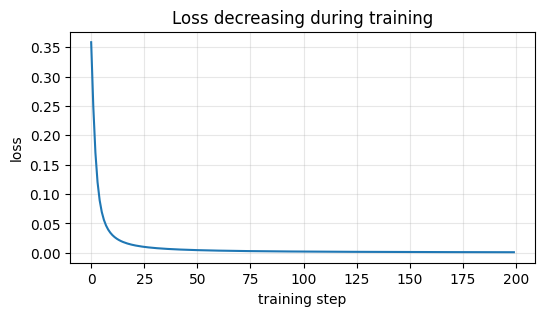

In [12]:
import matplotlib.pyplot as plt

w1_t = torch.tensor(0.5,  requires_grad=True)
w2_t = torch.tensor(-0.5, requires_grad=True)
b_t  = torch.tensor(0.1,  requires_grad=True)

losses = []
n_steps = 200

for step in range(n_steps):
    z_t     = w1_t * x1 + w2_t * x2 + b_t
    y_hat_t = torch.sigmoid(z_t)
    loss_t  = (y_hat_t - y_true) ** 2

    loss_t.backward()

    with torch.no_grad():
        w1_t -= lr * w1_t.grad
        w2_t -= lr * w2_t.grad
        b_t  -= lr * b_t.grad

        w1_t.grad.zero_()
        w2_t.grad.zero_()
        b_t.grad.zero_()

    losses.append(loss_t.item())

print(f'Final  : y_hat = {y_hat_t.item():.4f}  (target {y_true}),  loss = {losses[-1]:.6f}')
print(f'Learned: w1 = {w1_t.item():.4f},  w2 = {w2_t.item():.4f},  b = {b_t.item():.4f}')

plt.figure(figsize=(6, 3))
plt.plot(losses)
plt.xlabel('training step')
plt.ylabel('loss')
plt.title('Loss decreasing during training')
plt.grid(True, alpha=0.3)
plt.show()